In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('E-Commerce _Sales_Analysis .csv')
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Column 1,Column 2
0,10001,10/19/2024,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68959,10525,Debit Card,NaN,NaN
1,10002,8/30/2025,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732,6300,Debit Card,NaN,NaN
2,10003,11/4/2023,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603,19850,Credit Card,NaN,NaN
3,10004,5/23/2025,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610,36311,UPI,NaN,NaN
4,10005,1/19/2025,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033,9050,Debit Card,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   str    
 2   Customer Name  5000 non-null   str    
 3   Region         5000 non-null   str    
 4   City           5000 non-null   str    
 5   Category       5000 non-null   str    
 6   Sub-Category   5000 non-null   str    
 7   Product Name   5000 non-null   str    
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   int64  
 12  Profit         5000 non-null   int64  
 13  Payment Mode   5000 non-null   str    
 14  Column 1       0 non-null      float64
 15  Column 2       0 non-null      float64
dtypes: float64(2), int64(6), str(8)
memory usage: 625.1 KB


In [5]:
df.isnull().sum()

Order ID            0
Order Date          0
Customer Name       0
Region              0
City                0
Category            0
Sub-Category        0
Product Name        0
Quantity            0
Unit Price          0
Discount            0
Sales               0
Profit              0
Payment Mode        0
Column 1         5000
Column 2         5000
dtype: int64

In [6]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit,Column 1,Column 2
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,0.0,0.0
mean,12500.500000,2.992600,39760.904600,10.051000,106733.239400,15941.751200,NaN,NaN
std,1443.520003,1.413133,22831.783946,7.084662,85108.224277,14897.689993,NaN,NaN
min,10001.000000,1.000000,222.000000,0.000000,264.000000,19.000000,NaN,NaN
25%,11250.750000,2.000000,20312.250000,5.000000,39766.500000,4892.500000,NaN,NaN
50%,12500.500000,3.000000,39459.500000,10.000000,83080.000000,11108.500000,NaN,NaN
75%,13750.250000,4.000000,59721.750000,15.000000,156968.500000,22467.500000,NaN,NaN
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.000000,NaN,NaN


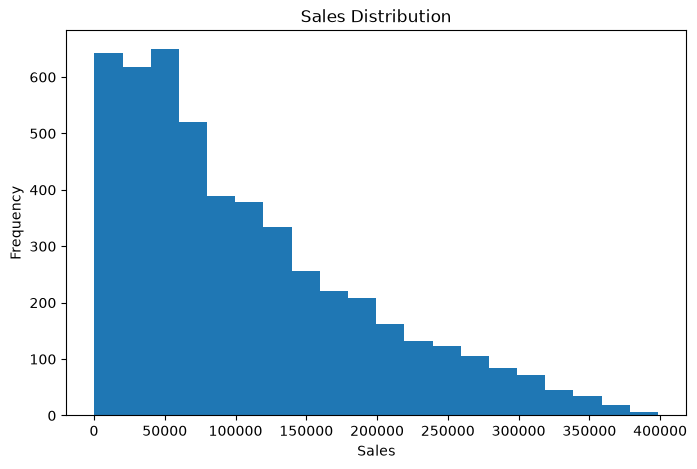

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins= 20)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

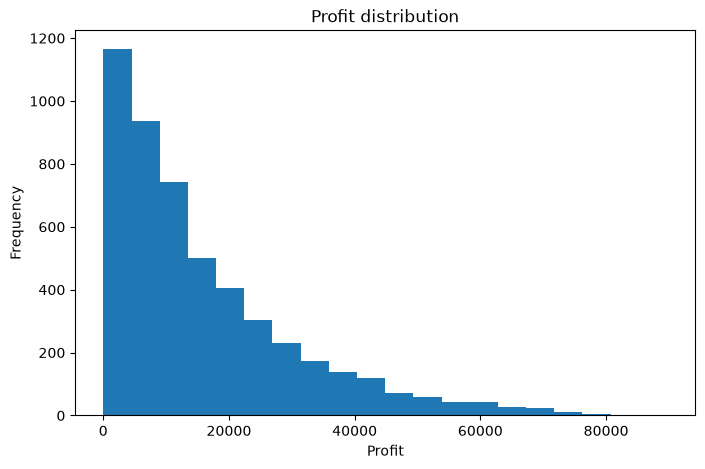

In [8]:
plt.figure(figsize =(8,5))
plt.hist(df['Profit'], bins =20)
plt.title('Profit distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

In [9]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.088516
Profit,-0.088516,1.000000


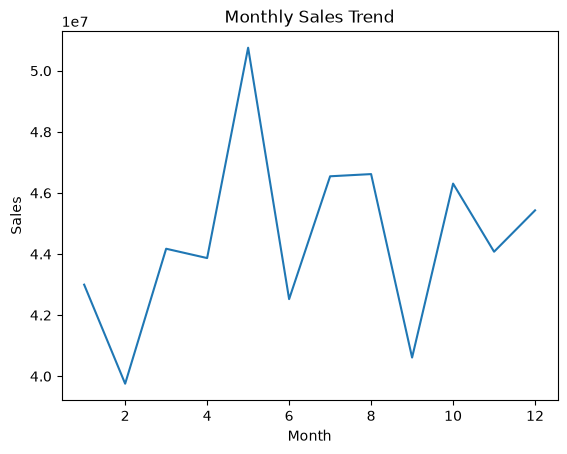

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

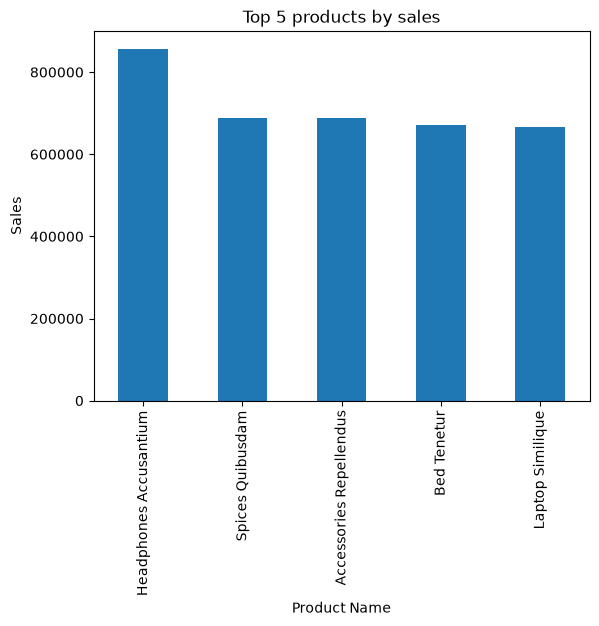

In [11]:
df.groupby('Product Name')['Sales'].sum().nlargest(5).plot(kind ='bar')
plt.title('Top 5 products by sales')
plt.ylabel('Sales')
plt.show()


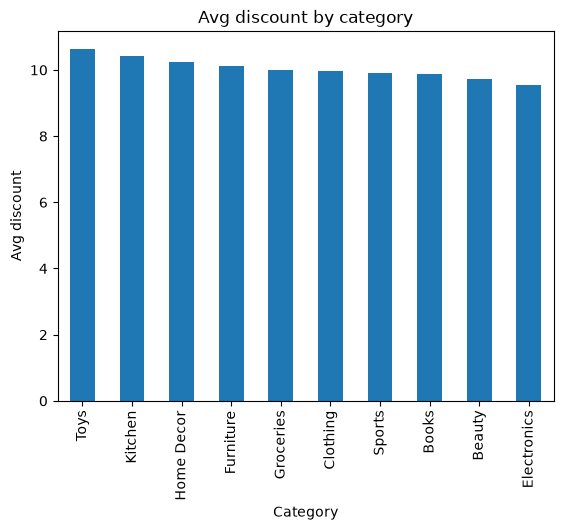

In [12]:
df.groupby('Category')['Discount'].mean().sort_values(ascending= False).plot(kind ='bar')
plt.title('Avg discount by category')
plt.ylabel('Avg discount')
plt.show()

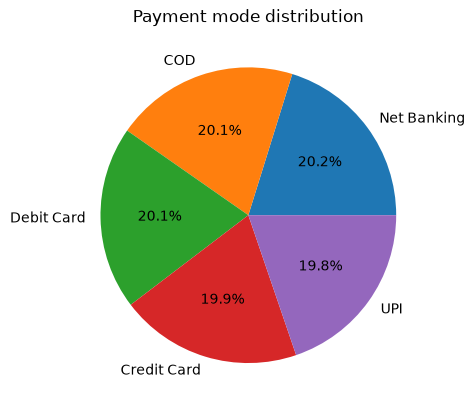

In [13]:
df['Payment Mode'].value_counts().plot(kind='pie' , autopct="%1.1f%%")
plt.title('Payment mode distribution')

plt.show()

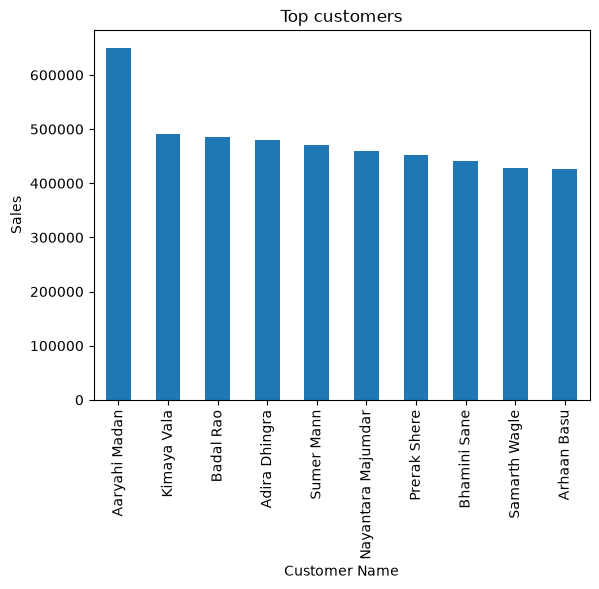

In [16]:
top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10)
top_customers.plot(kind = 'bar')
plt.title('Top customers')
plt.ylabel('Sales')
plt.show()

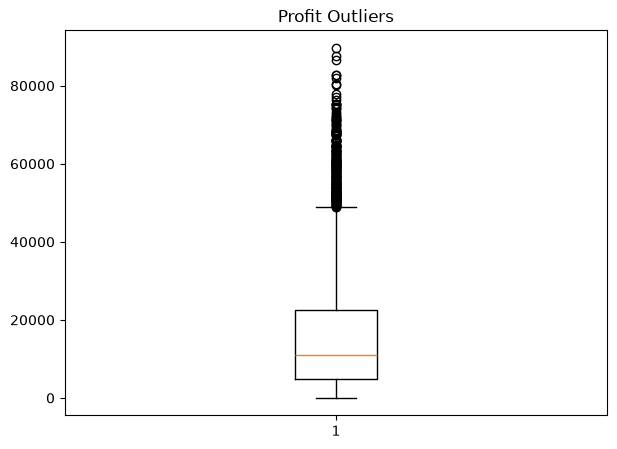

In [18]:
plt.figure(figsize=(7,5))
plt.boxplot(df['Profit'])
plt.title('Profit Outliers')
plt.show()

In [ ]:
#Most profits are between ₹5,000 and ₹22,000.
#1. The typical (median) profit is around ₹10,000.
#2. There are many unusually large profits.
#3. The data has many high-profit outliers, ranging from about ₹48,000 up to ₹90,000.
#4. The distribution is right-skewed (positively skewed) because there are many large values on the higher end.

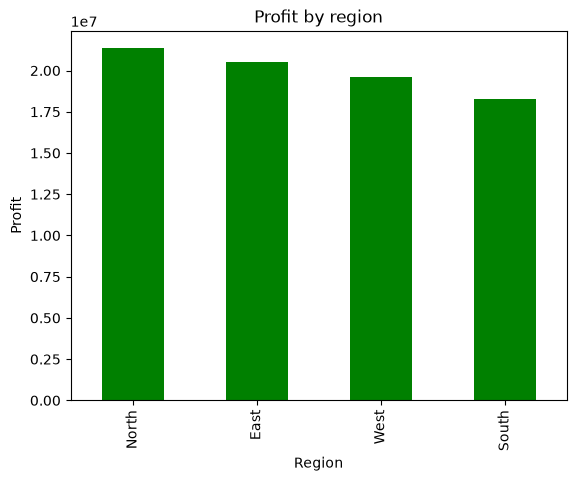

In [26]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False).plot(kind ='bar', color='green')
plt.title('Profit by region')
plt.ylabel('Profit')
plt.show()
